# Der Ton der US-Notenbank als Zinssignal

Schriftliche Ausarbeitung im Modul Natural Language Processing, Sommersemester 2026

Fachhochschule Südwestfalen, Masterstudiengang Angewandte Künstliche Intelligenz

Dozent Prof. Dr. Christian Gawron

Yurii Dobrytsia, Matrikelnummer 30518764

28.09.2026

## Zusammenfassung

Diese Arbeit untersucht, ob sich der geldpolitische Ton der US-Notenbank automatisch erkennen lässt und ob er Zinsänderungen ankündigt. Grundlage sind 2.480 von Hand bewertete Sätze aus dem Datensatz von Shah et al. (2023) und 214 Statements der Jahre 2000 bis 2025. Verglichen werden die Mehrheitsklasse, TF-IDF mit logistischer Regression und ein feinabgestimmtes RoBERTa-base. RoBERTa erreicht auf der Testmenge einen gewichteten F1 von 0,716 und liegt damit etwa auf dem Niveau der Veröffentlichung, TF-IDF kommt auf 0,598. Aus den Vorhersagen entsteht ein Ton-Index je Statement. Er folgt den Zinszyklen, hängt aber am stärksten mit den Zinsänderungen der vergangenen 6 Monate zusammen (0,587). Nach vorn ist der Zusammenhang schwach, und bei der Richtung der folgenden Monate schlägt der Index eine einfache Trendregel nicht. Die Statements erklären also vor allem, was die Notenbank gerade tut.

## Inhaltsverzeichnis

- Zusammenfassung
- 1 Problemstellung und Daten
- 2 Stand der Technik
- 3 Lösung und Evaluation
- 4 Kritische Reflexion und Fazit
- Literaturverzeichnis
- Erklärung

## 1 Problemstellung und Daten

### 1.1 Problem und Forschungsfrage

Nach jeder Sitzung veröffentlicht der Offenmarktausschuss der US-Notenbank (Federal Open Market Committee, FOMC) eine kurze Erklärung, das Statement. Darin steht die Zinsentscheidung, vor allem aber eine Einschätzung der Lage. An den Finanzmärkten wird jedes Wort gelesen, denn der Ton verrät, ob die Notenbank eher zu höheren Zinsen neigt oder zu niedrigeren. Im Fachjargon nennt man einen Ton, der auf höhere Zinsen hindeutet, hawkish, den gegenteiligen dovish. Im Folgenden verwende ich dafür restriktiv und expansiv. Wer Kredite aufnimmt, Anleihen hält oder Unternehmen bewertet, möchte diese Richtung möglichst früh kennen.

Mich interessiert das Thema auch aus der Praxis. Im landwirtschaftlichen Betrieb meiner Familie hängen Investitionen in Land und Maschinen direkt an den Finanzierungskosten, und bei Start-ups und Beteiligungen, mit denen ich mich beruflich beschäftige, bestimmt der Zins die Bewertung mit.

Die Arbeit besteht aus zwei Schritten. Zuerst soll ein Modell einzelne Sätze der Notenbank als restriktiv, expansiv oder neutral einordnen. Das ist eine Textklassifikation mit drei Klassen. Danach fasse ich die Vorhersagen für jedes Statement zu einem Ton-Index zusammen und prüfe, ob dieser Index den Zinsentscheidungen vorausläuft. Erst der zweite Schritt macht aus der Klassifikation eine Aussage, mit der man etwas anfangen kann. Daraus ergibt sich die Forschungsfrage.

**Wie genau lässt sich der geldpolitische Ton einzelner Sätze der US-Notenbank automatisch als restriktiv, expansiv oder neutral einordnen, und läuft ein daraus gebildeter Ton-Index den Zinsänderungen voraus?**

### 1.2 Daten

Für den ersten Schritt nutze ich den Datensatz von Shah et al. (2023). Er enthält von Hand bewertete Sätze aus Sitzungsprotokollen, Pressekonferenzen und Reden der Notenbank aus den Jahren 1996 bis 2022. Jeder Satz trägt eines von drei Labels. Die Autoren stellen die Daten unter der Lizenz CC BY-NC 4.0 auf Hugging Face bereit, bereits aufgeteilt in Training und Test. Die folgenden Zellen richten die Umgebung ein und laden die Daten.

In [1]:
%%capture
%pip install pandas==3.0.6 numpy==2.4.6 scikit-learn==1.9.1 matplotlib==3.11.2

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

RANDOM_STATE = 1977
DATA = Path('data')
NAMES = ['dovish', 'hawkish', 'neutral']  # Label 0, 1, 2 wie im Datensatz

In [3]:
train = pd.read_csv(DATA / 'fomc_train.csv')
test = pd.read_csv(DATA / 'fomc_test.csv')  # Aufteilung von Hugging Face, laut Dateiname Seed 944601
counts = pd.DataFrame({'train': train['label'].value_counts(), 'test': test['label'].value_counts()})
counts.index = [NAMES[i] for i in counts.index]
n = len(train) + len(test)
print(f'{n} Sätze, davon {len(train)} Training und {len(test)} Test ({len(test) / n:.0%})')
print(f'Jahre {train.year.min()} bis {train.year.max()}')
counts.T

2480 Sätze, davon 1984 Training und 496 Test (20%)
Jahre 1996 bis 2022


,neutral,dovish,hawkish
train,977,515,492
test,247,135,114


Knapp die Hälfte der Sätze ist neutral, restriktive und expansive Sätze sind etwa gleich häufig. Training und Test sind fast gleich zusammengesetzt, wie man es bei einer zufälligen Aufteilung erwartet. Die drei kurzen Beispiele unten zeigen, wie fein die Unterschiede sind.

In [4]:
# je ein kurzes Beispiel pro Klasse
pd.set_option('display.max_colwidth', 150)
short = train[train['sentence'].str.len().between(80, 150)]
examples = short.groupby('label').head(1).copy()
examples['klasse'] = examples['label'].map(dict(enumerate(NAMES)))
examples[['klasse', 'sentence']]

,klasse,sentence
2,neutral,"On balance, most participants still expected inflation to moderate later this year and in 2009."
4,dovish,But I want to emphasize that we do have a commitment to raising inflation to 2 percent.
11,hawkish,Our new statement explicitly acknowledges the challenges posed by the proximity of interest rates to the effective lower bound.


Der erste Satz erwartet eine nachlassende Inflation und gilt trotzdem als neutral. Der zweite gilt als expansiv, weil die Notenbank die Inflation auf 2 Prozent anheben will. Der dritte spricht über Zinsen nahe der Untergrenze und trägt das Label restriktiv, obwohl man ihn auch expansiv lesen könnte. Schon hier zeigt sich, dass die Labels nicht immer eindeutig sind.

Für den zweiten Schritt habe ich die Statements der Jahre 2000 bis 2025 von der Website der Notenbank geladen und in Sätze zerlegt. Das erledigt das Skript fetch_data.py im Ordner des Notebooks. Abstimmungslisten und die meisten Hinweise zum Diskontsatz habe ich entfernt, weil sie nichts über den Kurs aussagen. In den Jahren 2000 bis 2003 stehen einige dieser Hinweise im selben Absatz wie der übrige Text und sind geblieben. Den Leitzins liefert die Datenbank FRED der Federal Reserve Bank of St. Louis, bis Dezember 2008 als Zielwert und danach als Obergrenze des Zielbands.

In [5]:
statements = pd.read_csv(DATA / 'statements.csv', parse_dates=['date'])
rate = pd.read_csv(DATA / 'fed_target_rate.csv', parse_dates=['date']).set_index('date')['rate'].sort_index()
n_stat = statements['date'].nunique()
first, last = statements['date'].min(), statements['date'].max()
print(f'{n_stat} Statements mit {len(statements)} Sätzen, {first:%Y} bis {last:%Y}')
print(f'Leitzins-Zielwert von {rate.index.min():%d.%m.%Y} bis {rate.index.max():%d.%m.%Y}')

214 Statements mit 2776 Sätzen, 2000 bis 2025
Leitzins-Zielwert von 01.01.1999 bis 28.09.2026


Es sind 214 Statements mit zusammen 2.776 Sätzen. Das sind etwas mehr als 8 pro Jahr, weil die Notenbank in Krisen auch außerhalb der geplanten Sitzungen entschieden hat. Die Statements vom Dezember 2003 und vom Mai 2004 hat das Skript nicht gefunden.

## 2 Stand der Technik

Dass Texte von Notenbanken messbare Signale enthalten, ist in der Ökonomie gut belegt. Lucca und Trebbi (2009) bewerten 82 Statements von Mai 1999 bis Dezember 2008 automatisch. Statt eines trainierten Klassifikators messen sie über Trefferzahlen in der Google-Suche und in der Nachrichtendatenbank Factiva, wie oft Formulierungen zusammen mit Gegensatzpaaren wie hawkish und dovish auftreten. Sie finden, dass Änderungen im Inhalt der Statements den Zinsentscheidungen um mehr als ein Jahr vorauslaufen.

Shah et al. (2023) machen daraus eine Aufgabe für das maschinelle Lernen. Sie annotieren Sätze aus Protokollen, Pressekonferenzen und Reden und vergleichen ein Wörterbuchverfahren, rekurrente Netze, feinabgestimmte Transformer und ChatGPT ohne Training. Mit ihrem besten Modell, RoBERTa-large, bilden sie für jedes Dokument ein Maß aus der Zahl der restriktiven minus der expansiven Sätze, geteilt durch alle Sätze. Dieses Maß hängt deutlich mit der nächsten veröffentlichten Inflationsrate zusammen. Die Korrelation mit der Veränderung des Verbraucherpreisindex zum Vorjahr liegt bei 0,54. Die folgende Zelle hält ihre Ergebnisse für den kombinierten Datensatz mit geteilten Sätzen (Combined-S) fest, auf dem auch diese Arbeit aufsetzt.

In [6]:
# Shah et al. (2023), Tabelle 5, Combined-S, gewichteter F1, Mittel über 3 Seeds
# Shah et al. (2023), Tabelle 6: Korrelation ihres Maßes mit der folgenden Inflationsrate (CPI) 0.54
# Lucca und Trebbi (2009): 82 Statements von Mai 1999 bis Dezember 2008
literatur = pd.DataFrame({
    'Modell': ['Regelbasiert (Wörterbuch)', 'ChatGPT-3.5 ohne Training', 'BERT-base',
               'RoBERTa-base', 'RoBERTa-large'],
    'gewichteter F1': [0.5165, 0.5868, 0.6360, 0.6981, 0.7113],
    'Standardabweichung': [0.0064, 0.0131, 0.0225, 0.0097, 0.0106]})
literatur

,Modell,gewichteter F1,Standardabweichung
0,Regelbasiert (Wörterbuch),0.5165,0.0064
1,ChatGPT-3.5 ohne Training,0.5868,0.0131
2,BERT-base,0.6360,0.0225
3,RoBERTa-base,0.6981,0.0097
4,RoBERTa-large,0.7113,0.0106


Angegeben ist der gewichtete F1-Wert, gemittelt über 3 Seeds, die jeweils auch die zufällige Aufteilung in Training und Test festlegen. RoBERTa-large liegt mit 0,7113 vorn, knapp vor RoBERTa-base mit 0,6981. Das Wörterbuchverfahren, das in der Ökonomie lange Standard war, erreicht nur 0,5165, ChatGPT ohne Training 0,5868.

Ein Punkt bleibt in beiden Arbeiten offen. Shah et al. (2023) wenden ihr Maß nicht auf die kurzen Statements an und prüfen es an Inflation und Märkten, nicht am weiteren Verlauf des Leitzinses. Lucca und Trebbi (2009) prüfen genau diesen Vorlauf, ihre Daten enden aber 2008 und ihr Verfahren ist kein Sprachmodell. Diese Arbeit verbindet beide Ansätze. Papers with Code, das die Aufgabenstellung nennt, wird nicht mehr gepflegt. Die Recherche lief deshalb über die ACL Anthology, arXiv und die Seiten der Autoren.

## 3 Lösung und Evaluation

### 3.1 Vorgehen und Bewertungsmaße

Ich vergleiche drei Systeme auf derselben Testmenge. Die Mehrheitsklasse dient als Untergrenze. Das zweite System ist ein klassisches Verfahren aus der Vorlesung, TF-IDF-Merkmale aus Wörtern und Wortpaaren mit einer logistischen Regression (LR) mit ausgeglichenen Klassengewichten. Den Regularisierungsparameter C wähle ich per fünffacher Kreuzvalidierung auf den Trainingsdaten, die Testmenge bleibt dabei unberührt. Das dritte System ist RoBERTa-base (Liu et al., 2019), ein vortrainiertes Transformer-Modell, das ich auf den Trainingssätzen feinabgestimmt habe. Das Training lief bewusst auf der CPU eines eigenen Rechners und außerhalb des Notebooks im Skript train_roberta.py, mit festen Einstellungen, ohne Suche nach Hyperparametern und ohne eigene Validierungsdaten. Die Rechenserver der FH Südwestfalen oder ein Cloud-Dienst mit Grafikkarte wären ebenfalls möglich gewesen, für ein Basismodell mit 1.984 Trainingssätzen reicht die CPU aber aus. Das Notebook lädt die gespeicherten Vorhersagen.

Als Hauptmaß nutze ich wie Shah et al. (2023) den gewichteten F1-Wert, der jede Klasse nach ihrer Häufigkeit gewichtet. Daneben steht der Makro-F1, der alle drei Klassen gleich zählt und damit die selteneren Tonklassen stärker betont. Für jedes System gibt es Precision, Recall und F1 je Klasse sowie eine Konfusionsmatrix.

In [7]:
results, preds = {}, {}

def evaluate(name, pred):
    # Bericht je Klasse und die beiden F1-Werte für den Gesamtvergleich
    print(name)
    print(classification_report(test['label'], pred, target_names=NAMES, digits=3, zero_division=0))
    preds[name] = pred
    results[name] = {'gewichteter F1': f1_score(test['label'], pred, average='weighted'),
                     'Makro-F1': f1_score(test['label'], pred, average='macro')}

### 3.2 Mehrheitsklasse

In [8]:
majority = DummyClassifier(strategy='most_frequent')
majority.fit(train['sentence'], train['label'])
evaluate('Mehrheitsklasse', majority.predict(test['sentence']))

Mehrheitsklasse
              precision    recall  f1-score   support

      dovish      0.000     0.000     0.000       135
     hawkish      0.000     0.000     0.000       114
     neutral      0.498     1.000     0.665       247

    accuracy                          0.498       496
   macro avg      0.166     0.333     0.222       496
weighted avg      0.248     0.498     0.331       496



Die Mehrheitsklasse sagt immer neutral voraus. Das ergibt einen gewichteten F1 von 0,331 und einen Makro-F1 von 0,222. Jedes brauchbare Modell muss deutlich darüber liegen.

### 3.3 TF-IDF mit logistischer Regression

In [9]:
# C per fünffacher Kreuzvalidierung auf den Trainingsdaten, die Testmenge bleibt unberührt
pipe = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
                     LogisticRegression(max_iter=2000, class_weight='balanced'))
search = GridSearchCV(pipe, {'logisticregression__C': [0.3, 1, 3, 10, 30]}, scoring='f1_macro', cv=5)
search.fit(train['sentence'], train['label'])
tfidf = search.best_estimator_
best_c = search.best_params_['logisticregression__C']
print(f'bestes C {best_c}, Makro-F1 in der Kreuzvalidierung {search.best_score_:.3f}')
evaluate('TF-IDF + LR', tfidf.predict(test['sentence']))

bestes C 1, Makro-F1 in der Kreuzvalidierung 0.574
TF-IDF + LR
              precision    recall  f1-score   support

      dovish      0.547     0.563     0.555       135
     hawkish      0.508     0.526     0.517       114
     neutral      0.669     0.648     0.658       247

    accuracy                          0.597       496
   macro avg      0.575     0.579     0.577       496
weighted avg      0.599     0.597     0.598       496



Die Kreuzvalidierung wählt C = 1. Auf der Testmenge erreicht das Modell einen gewichteten F1 von 0,598. Neutrale Sätze erkennt es am besten (F1 0,658), restriktive am schlechtesten (0,517). Damit liegt das einfache Modell etwa auf der Höhe von ChatGPT ohne Training und klar über dem Wörterbuchverfahren aus der Literatur.

### 3.4 Feinabgestimmtes RoBERTa

In [10]:
# feinabgestimmt mit train_roberta.py, hier nur die gespeicherten Ausgaben laden
log = json.loads((DATA / 'protokoll_roberta.json').read_text())
print(f"{log['model']}, lr {log['lr']}, Batch {log['batch']}, {log['epochs']} Epochen, Seed {log['seed']}")
print(f"Trainingszeit {log['train_seconds'] / 60:.0f} Minuten auf der CPU, Verlust je Epoche {log['loss']}")
evaluate('RoBERTa-base', np.load(DATA / 'proba_roberta_test.npy').argmax(axis=1))

roberta-base, lr 2e-05, Batch 16, 4 Epochen, Seed 1977
Trainingszeit 31 Minuten auf der CPU, Verlust je Epoche [1.0136, 0.7661, 0.5592, 0.4213]
RoBERTa-base
              precision    recall  f1-score   support

      dovish      0.649     0.711     0.678       135
     hawkish      0.620     0.702     0.658       114
     neutral      0.813     0.721     0.764       247

    accuracy                          0.714       496
   macro avg      0.694     0.711     0.700       496
weighted avg      0.724     0.714     0.716       496



Das Training dauerte 31 Minuten, der Trainingsverlust fiel über die 4 Epochen von 1,0136 auf 0,4213. RoBERTa-base erreicht einen gewichteten F1 von 0,716 und einen Makro-F1 von 0,700. Der F1-Wert steigt in allen drei Klassen deutlich, bei restriktiven Sätzen etwa von 0,517 auf 0,658 und bei expansiven von 0,555 auf 0,678.

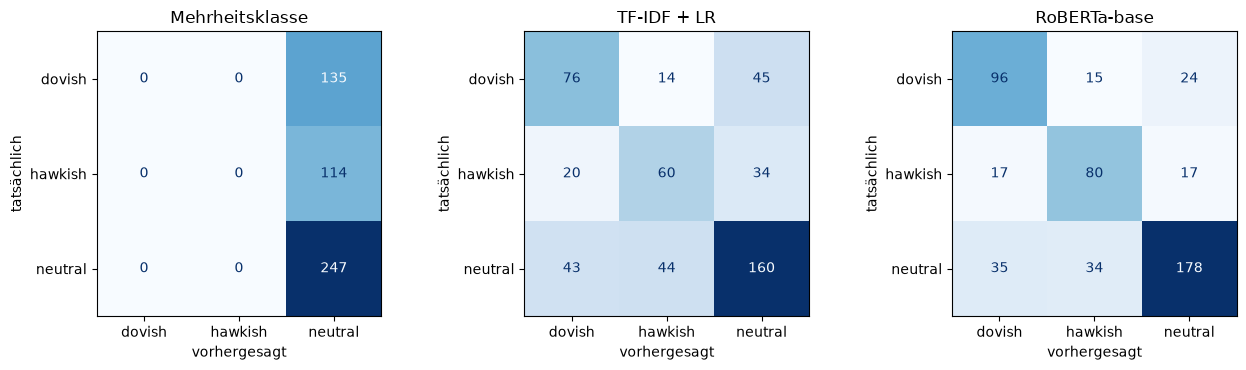

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, pred) in zip(axes, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(test['label'], pred), display_labels=NAMES).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set(title=name, xlabel='vorhergesagt', ylabel='tatsächlich')
plt.tight_layout()
plt.show()

**Abbildung 1:** Konfusionsmatrizen der drei Systeme auf den 496 Testsätzen

Bei RoBERTa liegen die meisten Fehler zwischen einer Tonklasse und neutral. Restriktiv und expansiv verwechselt das Modell seltener. Am häufigsten hält es neutrale Sätze für restriktiv oder expansiv. Das passt zur Aufgabe, denn ein vorsichtig formulierter Satz liegt oft an der Grenze zu neutral, während eine klare Richtung selten ins Gegenteil kippt.

### 3.5 Gesamtvergleich

In [12]:
pd.DataFrame(results).T.round(3)

,gewichteter F1,Makro-F1
Mehrheitsklasse,0.331,0.222
TF-IDF + LR,0.598,0.577
RoBERTa-base,0.716,0.700


RoBERTa liegt in beiden Maßen klar vor TF-IDF, und beide liegen weit über der Mehrheitsklasse. Die Gewichte des TF-IDF-Modells zeigen, woran es den Ton festmacht.

In [13]:
# Wörter mit dem größten Gewicht je Klasse im TF-IDF-Modell
vocab = np.array(tfidf[0].get_feature_names_out())
coef = tfidf[1].coef_
pd.DataFrame({NAMES[k]: vocab[np.argsort(coef[k])[::-1][:8]] for k in range(3)})

,dovish,hawkish,neutral
0,lower,higher,monetary policy
1,subdued,rise,between
2,accommodative,tightening,monetary
3,low,rise in,changed
4,downside,up,or
5,percent,stability,changes in
6,unemployment,inflation,stock
7,down,solid,changes


Für expansiv stehen Wörter wie lower, subdued, accommodative und downside, für restriktiv higher, rise, tightening und inflation. Die neutrale Klasse sammelt Wörter ohne Richtung wie monetary policy oder changes. Das Modell lernt also im Kern ein Wörterbuch. Vermutlich scheitert es vor allem dort, wo dieselben Wörter verneint oder an Bedingungen geknüpft sind, und genau dort dürfte der Kontext helfen, den RoBERTa mitliest.

### 3.6 Ton-Index und Zinsentwicklung

Jetzt folgt der zweite Schritt. Für jedes Statement bildet der Index wie bei Shah et al. (2023) die Zahl der restriktiven minus der expansiven Sätze, geteilt durch alle Sätze. Er liegt also zwischen minus 1 und plus 1. Ich nutze die Vorhersagen von RoBERTa und zum Vergleich die von TF-IDF.

In [14]:
# Ton-Index je Statement wie bei Shah et al. (2023), (restriktiv minus expansiv) / alle Sätze
statements['pred'] = np.load(DATA / 'proba_roberta_statements.npy').argmax(axis=1)
statements['pred_tfidf'] = tfidf.predict(statements['sentence'])
def tone(labels):
    return ((labels == 1).sum() - (labels == 0).sum()) / len(labels)
index = statements.groupby('date').agg(ton=('pred', tone), ton_tfidf=('pred_tfidf', tone),
                                      saetze=('pred', 'size'))
print(f"Anteil restriktiv {np.mean(statements.pred == 1):.3f}, expansiv {np.mean(statements.pred == 0):.3f}, "
      f"neutral {np.mean(statements.pred == 2):.3f}")
index.describe().round(3).loc[['mean', 'std', 'min', 'max']]

Anteil restriktiv 0.282, expansiv 0.392, neutral 0.325


,ton,ton_tfidf,saetze
mean,-0.091,-0.226,12.972
std,0.339,0.292,5.344
min,-0.750,-0.786,4.000
max,0.750,0.800,26.000


RoBERTa hält 39,2 % der Statement-Sätze für expansiv, 28,2 % für restriktiv und nur 32,5 % für neutral, während im Trainingsdatensatz knapp die Hälfte neutral ist. Das kann an der knappen Sprache der Statements liegen, aber auch daran, dass das Modell neutrale Sätze zu oft einer Tonklasse zuordnet. Ohne eigene Labels lässt sich die Güte auf den Statements nicht prüfen. Im Mittel ist der Ton deshalb leicht expansiv, der Index liegt bei minus 0,091 und reicht von minus 0,75 bis plus 0,75. Abbildung 2 zeigt ihn zusammen mit dem Leitzins.

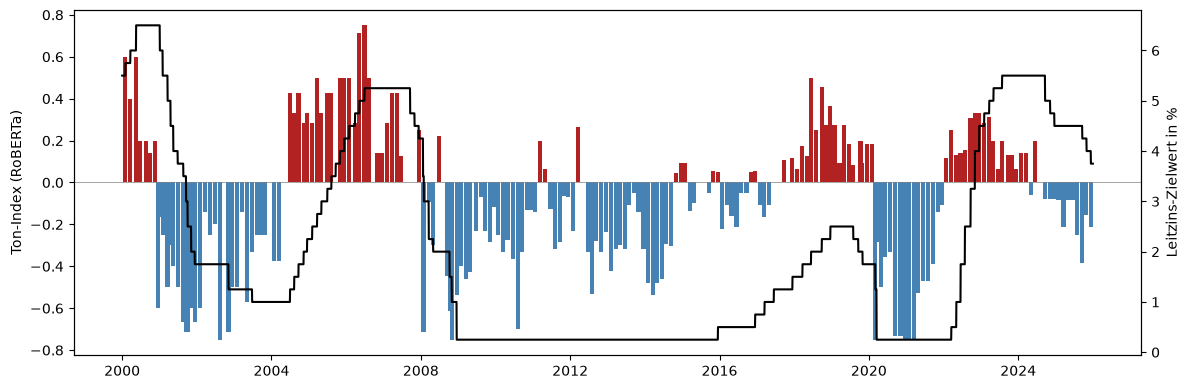

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(index.index, index['ton'], width=40, color=np.where(index['ton'] > 0, 'firebrick', 'steelblue'))
ax.set_ylabel('Ton-Index (RoBERTa)')
ax2 = ax.twinx()
ax2.plot(rate['2000-01-01':'2025-12-31'], color='black', lw=1.5)
ax2.set_ylabel('Leitzins-Zielwert in %')
ax.axhline(0, color='grey', lw=0.5)
plt.tight_layout()
plt.show()

**Abbildung 2:** Ton-Index je Statement (Balken, rot restriktiv, blau expansiv) und Leitzins (Linie, bis 2008 Zielwert, danach Obergrenze des Zielbands), 2000 bis 2025

In den Erhöhungsphasen 2004 bis 2006 und 2022 bis 2023 ist der Ton fast durchgehend restriktiv. 2022 dreht er schon eine Sitzung vor der ersten Erhöhung ins Positive, 2004 erst mit der Erhöhung selbst, allerdings fehlt dort das Statement vom Mai. In der langsamen Phase ab Ende 2015 bleibt er lange nahe null und wird erst 2018 deutlich restriktiv. Bei den Senkungen ist das Bild anders. 2001, 2008 und 2020 ist der Ton stark expansiv, 2001 sogar schon im Statement vor der ersten Senkung. Bei den Senkungen ab September 2007 bleibt er dagegen neutral oder restriktiv und wird erst im Januar 2008 expansiv. Während der Senkungen 2019 wird er nie expansiv, und bei denen ab September 2024 liegt er nur knapp unter null. In den langen Jahren mit Zinsen nahe null ist er meist expansiv. Der Index folgt den großen Zyklen also, reagiert aber nicht immer sofort und läuft den Wenden nur selten voraus. Ob er ihnen auch vorausläuft, zeigt die folgende Zelle. Sie misst für jedes Statement die Zinsänderung in den 6 Monaten davor und in den 3, 6, 12 und 24 Monaten danach, jeweils ab dem Tag nach der Entscheidung, und korreliert sie mit dem Index.

In [16]:
# Zinsänderung vor und nach jedem Statement, gemessen ab dem Tag nach der Entscheidung
def rate_at(day):
    return rate.asof(day)

rows = []
for date in index.index:
    base = rate_at(date + pd.Timedelta(days=1))  # Zins nach der Entscheidung dieses Tages
    row = {'davor 6 Monate': base - rate_at(date - pd.DateOffset(months=6))}
    for m in (3, 6, 12, 24):
        end = date + pd.DateOffset(months=m)
        row[f'danach {m} Monate'] = rate_at(end) - base if end <= rate.index.max() else np.nan
    rows.append(row)
changes = pd.DataFrame(rows, index=index.index)
corr = pd.DataFrame({'RoBERTa-Index': changes.corrwith(index['ton']),
                     'TF-IDF-Index': changes.corrwith(index['ton_tfidf']),
                     'Zinstrend davor': changes.corrwith(changes['davor 6 Monate']),
                     'Statements': changes.count()})
corr.round(3)

,RoBERTa-Index,TF-IDF-Index,Zinstrend davor,Statements
davor 6 Monate,0.587,0.335,1.000,214
danach 3 Monate,0.392,0.134,0.554,214
danach 6 Monate,0.284,0.083,0.553,214
danach 12 Monate,0.128,-0.112,0.419,212
danach 24 Monate,-0.209,-0.370,0.186,204


Am stärksten hängt der Index mit der Zinsänderung der vorangegangenen 6 Monate zusammen (0,587), einschließlich der Entscheidung am selben Tag. Nach vorn wird der Zusammenhang schnell schwächer, von 0,392 für 3 Monate über 0,284 für 6 Monate auf 0,128 für 12 Monate. Über 24 Monate kehrt er sich sogar um (minus 0,209), weil auf eine Phase mit Erhöhungen meist eine mit Senkungen folgt. Der Index aus den TF-IDF-Vorhersagen zeigt dasselbe Muster, aber deutlich schwächer (0,335 rückblickend und 0,134 für 3 Monate). Ein besserer Klassifikator liefert also auch ein klareres Signal.

Zwei Einschränkungen gelten aber. Jedes Statement nennt auch die Entscheidung des Tages, und solche Sätze tragen die Richtung schon in sich. Ein Teil des Zusammenhangs mit der vergangenen Änderung ist also mechanisch. Außerdem halten Zinszyklen meist über Monate an. Die Zinsänderung der letzten 6 Monate hängt mit der Änderung der nächsten 3 Monate sogar stärker zusammen (0,554) als der Index. Der Zusammenhang nach vorn kommt also zu einem guten Teil vom laufenden Trend.

Als letzte Probe dient eine einfache Richtungsprognose. Ist der Index positiv, sage ich einen Zinsanstieg im folgenden Zeitraum voraus. Zum Vergleich stehen zwei naive Regeln. Die eine sagt nie einen Anstieg voraus, die andere immer dann, wenn der Zins in den letzten 6 Monaten gestiegen ist.

In [17]:
# einfache Richtungsprognose: steigt der Zins im Zeitraum nach dem Statement oder nicht
rows = {}
for m in (3, 6, 12):
    future = changes[f'danach {m} Monate'].dropna()
    up = future > 0
    rows[f'{m} Monate'] = {'Anstiege': up.sum(), 'Statements': len(up),
                           'Ton-Index > 0': ((index['ton'][up.index] > 0) == up).mean(),
                           'Zins zuletzt gestiegen': ((changes['davor 6 Monate'][up.index] > 0) == up).mean(),
                           'immer kein Anstieg': (~up).mean()}
pd.DataFrame(rows).T.round(3).astype({'Anstiege': int, 'Statements': int})

,Anstiege,Statements,Ton-Index > 0,Zins zuletzt gestiegen,immer kein Anstieg
3 Monate,45,214,0.771,0.841,0.790
6 Monate,59,214,0.734,0.832,0.724
12 Monate,70,212,0.670,0.778,0.670


Über 3 Monate liegt die Trefferquote des Index bei 0,771, die Regel ohne Anstieg aber in 0,790 und die Trendregel in 0,841. Über 12 Monate liegt der Index mit 0,670 gleichauf mit der Regel ohne Anstieg, die Trendregel erreicht 0,778. Der Ton enthält also kaum Information über die künftige Richtung, die nicht schon in der jüngsten Zinsentwicklung steckt.

## 4 Kritische Reflexion und Fazit

### 4.1 Vergleich mit dem Stand der Technik

Bei der Klassifikation liegt mein RoBERTa-base mit 0,716 im gewichteten F1 über dem Mittelwert von RoBERTa-base bei Shah et al. (2023) mit 0,6981 und sogar knapp über RoBERTa-large mit 0,7113. Ich habe aber nur einen Lauf auf der Aufteilung von Hugging Face gemacht, die laut Dateiname zu einem der 3 Seeds des Papers gehört. Die Werte von Shah et al. (2023) sind Mittel über alle 3 Seeds, mit Standardabweichungen von 0,0097 und 0,0106. Der Vorsprung belegt also kein besseres Modell. Er spricht aber dafür, dass schon RoBERTa-base mit festen Einstellungen auf einer CPU etwa das Niveau der Veröffentlichung erreicht. Das einfache TF-IDF-Modell kommt mit 0,598 auf die Höhe von ChatGPT ohne Training und liegt über dem Wörterbuch, das in der Ökonomie lange Standard war.

Einen so langen Vorlauf wie Lucca und Trebbi (2009), die mehr als ein Jahr fanden, zeigen meine Daten nicht. Nach vorn gibt es nur über wenige Monate einen Zusammenhang, und bei der Richtung schlägt der Ton eine einfache Trendregel nicht. Die Ansätze unterscheiden sich allerdings stark. Ich nutze den Stand des Tons und einfache Korrelationen, sie nutzen seine Änderungen, berücksichtigen die Erwartungen aus Futures-Kursen und schätzen Modelle mit Inflation und Konjunktur, und ihr Zeitraum endet 2008.

### 4.2 Schwierigkeiten und Grenzen

Die größte praktische Schwierigkeit war das Sammeln der Statements. Die Website der Notenbank nutzt je nach Jahrgang drei verschiedene Seitenformate, und der erste Versuch fand nur einen Teil der Statements. Erst nach mehreren Anpassungen des Skripts waren es 214. Das Training von RoBERTa dauerte auf der CPU 31 Minuten. Ich habe mich bewusst für einen einzelnen Lauf mit festen Einstellungen entschieden, obwohl die Rechenserver der FH Südwestfalen oder ein Cloud-Dienst mit Grafikkarte auch mehrere Seeds und eine Suche nach Hyperparametern erlaubt hätten.

Inhaltlich sehe ich drei Grenzen. Erstens ist das Label selbst unscharf. Schon das dritte Beispiel in Abschnitt 1.2 lässt sich auch anders lesen, und die meisten Fehler des Modells liegen an der Grenze zu neutral. Zweitens wurde der Klassifikator auf Sätzen bis 2022 trainiert und bewertet dann Statements aus denselben Jahren. Shah et al. (2023) nennen diese Gefahr eines Vorgriffs auf spätere Daten ausdrücklich, finden bei einer zeitlichen Aufteilung aber keinen Hinweis, dass der F1-Wert davon profitiert. Für den Index kommt hinzu, dass einige Standardsätze der Statements wörtlich in den Trainingsdaten stehen. Für eine echte Prognose dürfte das Modell nur Sätze kennen, die vor dem jeweiligen Statement lagen. Drittens beruht die Zeitreihe auf wenigen Zinszyklen. Zwischen 2000 und 2025 gibt es nur eine Handvoll Wendepunkte, und die langen Phasen mit Zinsen nahe null bringen keine Änderungen. Weil sich die Zeiträume benachbarter Statements überschneiden, sind die 214 Werte zudem nicht unabhängig. Die Korrelationen beschreiben deshalb eher, als dass sie einen belastbaren Test liefern.

### 4.3 Was ich gelernt habe und Fazit

Gelernt habe ich vor allem zwei Dinge. Ein feinabgestimmtes Sprachmodell ist bei einer so subtilen Aufgabe wie dem Ton klar besser als ein Modell, das nur einzelne Wörter gewichtet, und dieser Vorsprung trägt bis in die Anwendung, denn der RoBERTa-Index folgt der Geldpolitik viel deutlicher als der TF-IDF-Index. Gleichzeitig ist ein gutes Klassifikationsergebnis noch keine gute Prognose. Was ein Maß über die Zukunft sagt, muss man getrennt prüfen, am besten gegen eine naive Regel.

Damit lässt sich die Forschungsfrage beantworten. Den geldpolitischen Ton einzelner Sätze erkennt ein feinabgestimmtes RoBERTa-base mit einem gewichteten F1 von 0,716, deutlich besser als TF-IDF mit 0,598 und die Mehrheitsklasse mit 0,331. Der daraus gebildete Ton-Index folgt den Zinszyklen von 2000 bis 2025, läuft ihnen aber kaum voraus. Er hängt am stärksten mit den Zinsänderungen der vergangenen 6 Monate zusammen, nach vorn gibt es nur für 3 Monate einen mittleren Zusammenhang, der zum größten Teil aus dem laufenden Zinstrend stammt. Bei der Richtung liegt der Index in allen Zeiträumen hinter der einfachen Trendregel, über 3 Monate sogar hinter der Regel, dass der Zins nicht steigt. Die Notenbank erklärt in ihren Statements also vor allem, was sie gerade tut. Wer ihre nächsten Schritte vorhersagen will, bräuchte vermutlich zusätzlich andere Daten wie Inflation und Arbeitsmarkt oder die ausführlicheren Protokolle.

## Literaturverzeichnis

Board of Governors of the Federal Reserve System. (2026). *Meeting calendars, statements, and minutes*. Abgerufen am 28.09.2026 von https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm

Federal Reserve Bank of St. Louis. (2026). *Federal funds target rate, Reihen DFEDTAR und DFEDTARU*. FRED. Abgerufen am 28.09.2026 von https://fred.stlouisfed.org

Liu, Y., Ott, M., Goyal, N., Du, J., Joshi, M., Chen, D., Levy, O., Lewis, M., Zettlemoyer, L., & Stoyanov, V. (2019). *RoBERTa: A robustly optimized BERT pretraining approach*. arXiv:1907.11692. https://arxiv.org/abs/1907.11692

Lucca, D. O., & Trebbi, F. (2009). *Measuring central bank communication: An automated approach with application to FOMC statements* (NBER Working Paper 15367). National Bureau of Economic Research. https://www.nber.org/papers/w15367

Shah, A., Paturi, S., & Chava, S. (2023). Trillion dollar words: A new financial dataset, task & market analysis. In *Proceedings of the 61st Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)* (S. 6664-6679). Association for Computational Linguistics. https://aclanthology.org/2023.acl-long.368

## Erklärung

Ich erkläre hiermit, dass ich die vorliegende Arbeit selbstständig verfasst und dabei keine anderen als die angegebenen Hilfsmittel benutzt habe. Sämtliche Stellen der Arbeit, die im Wortlaut oder dem Sinn nach Werken anderer Autoren entnommen sind, habe ich als solche kenntlich gemacht. Die Arbeit wurde bisher weder gesamt noch in Teilen einer anderen Prüfungsbehörde vorgelegt und auch noch nicht veröffentlicht.

28.09.2026

Yurii Dobrytsia